# Кредитный скоринг — версия 3

Продолжение `credit_scoring_v2`. Сплиты те же, модель одна: **CatBoost**.

| Что меняем | Зачем |
|------------|--------|
| Не удаляем пропуски, не скалируем, не кодируем категории | Числовые NaN CatBoost ест сам; в категориях пропуск помечаем строкой `__missing__` и передаём в `cat_features` |
| `eval_set` = валидация | Ранняя остановка по val, без подглядывания в late_test |
| Топы IV + F-score + FSTR → stage_2 | Три разных взгляда на важность, порог `n` смотрим по Gini на **test** |
| Корреляции и жадный отбор по FSTR → stage_3 | Убираем дубли; порог корреляции и число фичей — тоже по **test** |
| Калибровка порога и late_test | Как в v1/v2: порог по F1 на val, честная оценка в конце |

**Главная метрика ранжирования:** Gini. **После порога:** F1 по дефолту.

Гиперпараметры отбора крутим по test; `late_test` трогаем один раз в конце.


## 0. Импорты и настройки

`RANDOM_STATE` и `SAMPLE_SIZE` те же, что в v1 — сэмпл train совпадёт.


In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from optbinning import BinningProcess
from scipy.stats.contingency import association
from tqdm.auto import tqdm
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from IPython.display import display

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

RANDOM_STATE = 42
SAMPLE_SIZE = 50_000

# сколько брать из каждого топа (IV / F / FSTR) в stage_2; качество смотрим на test
STAGE2_N_OPTIONS = [20, 35, 50]

# жадный отбор stage_3: порог корреляции и сколько фичей оставить
CORR_THR_OPTIONS = [0.70, 0.80, 0.90]
STAGE3_N_OPTIONS = [15, 25, 35]

CATBOOST_PARAMS = {
    'iterations': 400,
    'learning_rate': 0.08,
    'depth': 6,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'auto_class_weights': 'Balanced',
    'random_seed': RANDOM_STATE,
    'verbose': False,
    'allow_writing_files': False,
    'early_stopping_rounds': 50,
}

PROJECT_DIR = Path('.').resolve()
SPLITS_DIR = PROJECT_DIR / 'data' / 'splits'

np.random.seed(RANDOM_STATE)
print('Проект:', PROJECT_DIR)
print('Сплиты:', SPLITS_DIR)


In [ ]:
def gini_score(y_true, y_proba) -> float:
    """Gini = 2 * ROC-AUC - 1."""
    return 2 * roc_auc_score(y_true, y_proba) - 1


def classification_at_threshold(y_true, y_proba, threshold: float) -> dict:
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'threshold': threshold,
        'F1': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Recall': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    }


def fit_catboost(X_tr, y_tr, X_va, y_va, cat_cols):
    """Учим CatBoost: категории в cat_features, val — в eval_set."""
    cats = [c for c in cat_cols if c in X_tr.columns]
    model = CatBoostClassifier(**CATBOOST_PARAMS)
    model.fit(
        X_tr, y_tr,
        cat_features=cats,
        eval_set=(X_va, y_va),
        use_best_model=True,
    )
    return model


def fstr_series(model, columns) -> pd.Series:
    return pd.Series(model.get_feature_importance(), index=columns, name='FSTR').sort_values(ascending=False)


## 1. Загрузка сплитов и сэмпл train

Те же файлы, что сохранила v1. Сэмплируем только train.


In [3]:
df_train = pd.read_csv(SPLITS_DIR / 'train.csv')
df_val = pd.read_csv(SPLITS_DIR / 'val.csv')
df_test = pd.read_csv(SPLITS_DIR / 'test.csv')
df_late = pd.read_csv(SPLITS_DIR / 'late_test.csv')

print('Загружено из data/splits/:')
for name, part in [('train', df_train), ('val', df_val), ('test', df_test), ('late_test', df_late)]:
    print(f'  {name:10s} {part.shape[0]:7,} × {part.shape[1]}')


Загружено из data/splits/:
  train      180,970 × 63
  val         25,853 × 63
  test        25,854 × 63
  late_test   25,853 × 63


In [4]:
df_train_full = df_train.copy()

if SAMPLE_SIZE < len(df_train_full):
    df_train, _ = train_test_split(
        df_train_full,
        train_size=SAMPLE_SIZE,
        stratify=df_train_full['target'],
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    df_train = df_train.reset_index(drop=True)

print(f'train полный:  {len(df_train_full):,}')
print(f'train сэмпл:   {len(df_train):,}')
print(f'доля дефолтов: полный {df_train_full["target"].mean():.3%} | сэмпл {df_train["target"].mean():.3%}')


train полный:  180,970
train сэмпл:   50,000
доля дефолтов: полный 8.086% | сэмпл 8.086%


## 2. Новые признаки

Считаем **по каждой заявке отдельно**. Пропуски не трогаем: деление на ноль даёт NaN, CatBoost это переживёт.


In [5]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    cols = set(out.columns)

    if 'days_birth' in cols:
        out['age_years'] = -out['days_birth'] / 365.25
    if 'days_employed' in cols:
        out['years_employed'] = -out['days_employed'] / 365.25

    if {'loan_body', 'income'} <= cols:
        out['credit_income_ratio'] = out['loan_body'] / out['income'].replace(0, np.nan)
    if {'annuity_payment', 'income'} <= cols:
        out['annuity_income_ratio'] = out['annuity_payment'] / out['income'].replace(0, np.nan)
        out['high_payment_burden'] = (out['annuity_income_ratio'] > 0.4).astype(float)
    if {'days_employed', 'days_birth'} <= cols:
        out['employed_to_age_ratio'] = out['days_employed'] / out['days_birth'].replace(0, np.nan)
    if {'goods_price', 'loan_body'} <= cols:
        out['goods_credit_ratio'] = out['goods_price'] / out['loan_body'].replace(0, np.nan)
        out['down_payment'] = out['goods_price'] - out['loan_body']
        out['down_payment_ratio'] = out['down_payment'] / out['goods_price'].replace(0, np.nan)
    if {'annuity_payment', 'loan_body'} <= cols:
        out['annuity_to_credit'] = out['annuity_payment'] / out['loan_body'].replace(0, np.nan)

    for src, dst in [('income', 'log_income'), ('loan_body', 'log_loan_body'),
                     ('annuity_payment', 'log_annuity'), ('goods_price', 'log_goods_price')]:
        if src in cols:
            out[dst] = np.log1p(out[src])

    if {'income', 'family_members__count'} <= cols:
        out['income_per_family_member'] = out['income'] / out['family_members__count'].replace(0, np.nan)
    if {'income', 'children_count'} <= cols:
        out['income_per_child'] = out['income'] / (out['children_count'] + 1)
    if {'children_count', 'family_members__count'} <= cols:
        out['children_share'] = out['children_count'] / out['family_members__count'].replace(0, np.nan)
    if {'loan_body', 'family_members__count'} <= cols:
        out['loan_per_family_member'] = out['loan_body'] / out['family_members__count'].replace(0, np.nan)

    ext = [c for c in ('external_source_2', 'external_source_3') if c in cols]
    if ext:
        out['ext_source_mean'] = out[ext].mean(axis=1)
        out['ext_source_min'] = out[ext].min(axis=1)
        out['ext_source_max'] = out[ext].max(axis=1)
        if len(ext) == 2:
            out['ext_source_diff'] = (out[ext[0]] - out[ext[1]]).abs()

    doc_cols = [c for c in out.columns if c.startswith('document_') and c.endswith('_flag')]
    if doc_cols:
        out['docs_count'] = out[doc_cols].sum(axis=1)

    phone_cols = [c for c in ('employee_phone_flag', 'work_phone_flag', 'phone_flag', 'email_flag') if c in cols]
    if phone_cols:
        out['contacts_count'] = out[phone_cols].sum(axis=1)

    req_cols = [c for c in out.columns if c.startswith('requests_bki_')]
    if req_cols:
        out['bki_requests_total'] = out[req_cols].sum(axis=1)

    if {'social_circle_defaults_30_days', 'observes_30_count_social_circle'} <= cols:
        out['social_default_rate_30'] = (
            out['social_circle_defaults_30_days'] / (out['observes_30_count_social_circle'] + 1)
        )
    if {'social_circle_defaults_60_days', 'observes_60_count_social_circle'} <= cols:
        out['social_default_rate_60'] = (
            out['social_circle_defaults_60_days'] / (out['observes_60_count_social_circle'] + 1)
        )

    if {'age_years', 'days_employed'} <= set(out.columns):
        out['young_low_exp'] = ((out['age_years'] < 25) & (out['days_employed'].abs() < 365)).astype(float)
    if {'rating_client_region', 'rating_client_w_city_region'} <= cols:
        out['region_city_rating_diff'] = out['rating_client_region'] - out['rating_client_w_city_region']

    if 'publication_timestamp' in cols:
        out['years_since_id_change'] = -out['publication_timestamp'] / 365.25
    if 'registration_timestamp' in cols:
        out['years_registered'] = -out['registration_timestamp'] / 365.25
    if 'last_phone_number_change' in cols:
        out['years_since_phone_change'] = -out['last_phone_number_change'] / 365.25

    return out


n_before = df_train.shape[1]
df_train = add_features(df_train)
df_val = add_features(df_val)
df_test = add_features(df_test)
df_late = add_features(df_late)
new_cols = [c for c in df_train.columns if c not in pd.read_csv(SPLITS_DIR / 'train.csv', nrows=0).columns]
print(f'Было колонок: {n_before}, стало: {df_train.shape[1]}')
print(f'Новых признаков ({len(new_cols)}):')
print(new_cols)


Было колонок: 63, стало: 95
Новых признаков (32):
['age_years', 'years_employed', 'credit_income_ratio', 'annuity_income_ratio', 'high_payment_burden', 'employed_to_age_ratio', 'goods_credit_ratio', 'down_payment', 'down_payment_ratio', 'annuity_to_credit', 'log_income', 'log_loan_body', 'log_annuity', 'log_goods_price', 'income_per_family_member', 'income_per_child', 'children_share', 'loan_per_family_member', 'ext_source_mean', 'ext_source_min', 'ext_source_max', 'ext_source_diff', 'docs_count', 'contacts_count', 'bki_requests_total', 'social_default_rate_30', 'social_default_rate_60', 'young_low_exp', 'region_city_rating_diff', 'years_since_id_change', 'years_registered', 'years_since_phone_change']


> **Примечание.** Новые признаки — отношения и суммы сырых полей. Аномалии на них по хорошему чистить,
> но в этой версии не чистим. Пропуски **не удаляем** и не заполняем.


## 3. Матрицы для CatBoost

Скалирование и One-Hot / Ordinal **не делаем**. Категории отдаём в `cat_features`.
`inf` из деления превращаем в NaN — это не удаление строк.


In [6]:
TARGET = 'target'
ID_COL = 'reco_id_curr'


def split_xy(frame: pd.DataFrame):
    y = frame[TARGET].astype(int)
    X = frame.drop(columns=[c for c in (TARGET, ID_COL) if c in frame.columns])
    return X, y


X_train, y_train = split_xy(df_train)
X_val, y_val = split_xy(df_val)
X_test, y_test = split_xy(df_test)
X_late, y_late = split_xy(df_late)

for frame in (X_train, X_val, X_test, X_late):
    frame.replace([np.inf, -np.inf], np.nan, inplace=True)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]
for frame in (X_train, X_val, X_test, X_late):
    for c in cat_cols:
        # CatBoost не принимает NaN в категориях — помечаем пропуск строкой, строки не удаляем
        frame[c] = frame[c].fillna('__missing__').astype(str)

print(f'Признаков: {X_train.shape[1]} (числовых {len(num_cols)}, категориальных {len(cat_cols)})')
print('Пропусков в train (ячейки):', int(X_train.isna().sum().sum()))
print('Строк не удаляли. Категории:', cat_cols)


Признаков: 93 (числовых 80, категориальных 13)
Пропусков в train (ячейки): 260908
Строк не удаляли. Категории: ['contract_type_name', 'gender', 'own_car_flag', 'own_realty_flag', 'type_suite_name', 'income_type_name', 'education_type_name', 'family_status_name', 'housing_type_name', 'type_of_occupation', 'start_weekday_appr_process', 'type_of_organization', 'emergency_state_mode']


## 4. IV, F-score и FSTR на всех признаках

Считаем **только на train**.

- **F-score (ОФА)** — `SelectKBest` + `f_classif`, **только числа**. Категории не кодируем и в ANOVA не берём.
- **IV** — `BinningProcess` (категории тоже, пропуски умеет сам).
- **FSTR** — важность CatBoost на **всех** фичах, включая категории, с `eval_set=val`.


In [7]:
def feature_scoring(col: str) -> dict:
    result = {'feature': col, 'IV': 0.0, 'F_score': np.nan, 'p_value': np.nan}

    # F-score (ОФА) — только числа; у категорий оставляем пропуск
    if col not in cat_cols:
        pair_f = pd.concat([X_train[[col]], y_train.rename('target')], axis=1).dropna()
        if len(pair_f) >= 50 and pair_f['target'].nunique() == 2 and pair_f[col].nunique() >= 2:
            f_sel = SelectKBest(score_func=f_classif, k='all')
            f_sel.fit(pair_f[[col]], pair_f['target'])
            result['F_score'] = float(f_sel.scores_[0])
            result['p_value'] = float(f_sel.pvalues_[0])

    cat_vars = [col] if col in cat_cols else None
    try:
        bp = BinningProcess(variable_names=[col], categorical_variables=cat_vars)
        bp.fit(X_train[[col]], y_train)
        result['IV'] = float(bp.get_binned_variable(col).binning_table.iv)
    except Exception:
        pass
    return result


rows = [feature_scoring(col) for col in tqdm(X_train.columns, desc='IV и F-score')]
scores = pd.DataFrame(rows)
iv_table = scores[['feature', 'IV']].sort_values('IV', ascending=False).reset_index(drop=True)
f_table = (
    scores.dropna(subset=['F_score'])[['feature', 'F_score', 'p_value']]
    .sort_values('F_score', ascending=False)
    .reset_index(drop=True)
)

print('Топ-15 по IV:')
display(iv_table.head(15))


IV и F-score:   0%|          | 0/93 [00:00<?, ?it/s]

Топ-15 по IV:


,feature,IV
0,ext_source_mean,0.559
1,ext_source_min,0.472
2,ext_source_max,0.421
3,external_source_2,0.348
4,external_source_3,0.308
5,annuity_to_credit,0.131
6,years_employed,0.111
7,days_employed,0.111
8,log_goods_price,0.110
9,goods_price,0.110


In [8]:
print('Топ-15 по F-score (только числа):')
display(f_table.head(15))


Топ-15 по F-score (только числа):


,feature,F_score,p_value
0,ext_source_mean,"2,364.958",0.000
1,ext_source_max,"1,915.100",0.000
2,ext_source_min,"1,821.555",0.000
3,external_source_2,"1,439.137",0.000
4,external_source_3,"1,177.564",0.000
5,down_payment_ratio,289.592,0.000
6,goods_credit_ratio,267.464,0.000
7,days_birth,249.484,0.000
8,age_years,249.484,0.000
9,days_employed,225.359,0.000


In [9]:
cb_all = fit_catboost(X_train, y_train, X_val, y_val, cat_cols)
fstr_all = fstr_series(cb_all, X_train.columns)
print(f'CatBoost на всех фичах | best iteration = {cb_all.get_best_iteration()} | Gini val = {gini_score(y_val, cb_all.predict_proba(X_val)[:, 1]):.4f}')
print('Топ-15 по FSTR:')
display(fstr_all.head(15).reset_index().rename(columns={'index': 'feature'}))


CatBoost на всех фичах | best iteration = 173 | Gini val = 0.4879
Топ-15 по FSTR:


,feature,FSTR
0,ext_source_mean,9.964
1,annuity_to_credit,7.722
2,education_type_name,3.125
3,gender,3.009
4,external_source_3,2.913
5,external_source_2,2.828
6,ext_source_min,2.749
7,age_years,2.702
8,employed_to_age_ratio,2.510
9,goods_price,2.407


## 5. Stage 2: объединение трёх топов

Для каждого `n` из `STAGE2_N_OPTIONS` берём топ-n по IV, по F-score и по FSTR, объединяем.
Учим CatBoost на этом пуле (`eval_set` = val), качество смотрим на **test**.
Победивший набор кладём в список `features_stage_2` — имена колонок в таблице не меняем.


In [10]:
def union_top(n):
    cols = iv_table['feature'].head(n).tolist()
    for col in f_table['feature'].head(n):
        if col not in cols:
            cols.append(col)
    for col in fstr_all.head(n).index:
        if col not in cols:
            cols.append(col)
    return cols


stage2_rows = []
for n in STAGE2_N_OPTIONS:
    cols = union_top(n)
    model = fit_catboost(X_train[cols], y_train, X_val[cols], y_val, cat_cols)
    gini_test = gini_score(y_test, model.predict_proba(X_test[cols])[:, 1])
    stage2_rows.append({'n': n, 'union': len(cols), 'gini_test': gini_test})
    print(f'n={n}, признаков={len(cols)}, Gini test={gini_test:.4f}')

stage2_search = pd.DataFrame(stage2_rows)
best_stage2_n = int(stage2_search.loc[stage2_search['gini_test'].idxmax(), 'n'])
print('Лучший n для stage_2:', best_stage2_n)
display(stage2_search)


n=20, признаков=34, Gini test=0.4820


n=35, признаков=51, Gini test=0.4825


n=50, признаков=68, Gini test=0.4866
Лучший n для stage_2: 50


,n,union,gini_test
0,20,34,0.482
1,35,51,0.482
2,50,68,0.487


In [11]:
features_stage_2 = union_top(best_stage2_n)
cat_cols_s2 = [c for c in features_stage_2 if c in cat_cols]

X_train_s2 = X_train[features_stage_2]
X_val_s2 = X_val[features_stage_2]
X_test_s2 = X_test[features_stage_2]
X_late_s2 = X_late[features_stage_2]

print(f'Пул stage_2: {len(features_stage_2)} признаков (union топ-{best_stage2_n} IV / F / FSTR)')
print('Категорий в пуле:', cat_cols_s2)


Пул stage_2: 68 признаков (union топ-50 IV / F / FSTR)
Категорий в пуле: ['type_of_occupation', 'type_of_organization', 'education_type_name', 'income_type_name', 'gender', 'emergency_state_mode', 'own_car_flag', 'family_status_name']


## 6. CatBoost на stage_2 и корреляции

На пуле `features_stage_2` снова учим CatBoost — его FSTR пойдёт в жадный отбор.

Корреляции на **train**, числа и категории **отдельно**:
- два числа → Пирсон и Спирмен, в матрицу берём максимум модуля;
- две категории → V Крамера (свой цикл).
Смешанные пары число–категория не считаем.


In [12]:
cb_s2 = fit_catboost(X_train_s2, y_train, X_val_s2, y_val, cat_cols_s2)
fstr_s2 = fstr_series(cb_s2, X_train_s2.columns)
print(f'CatBoost stage_2 | best iteration = {cb_s2.get_best_iteration()} | Gini val = {gini_score(y_val, cb_s2.predict_proba(X_val_s2)[:, 1]):.4f} | Gini test = {gini_score(y_test, cb_s2.predict_proba(X_test_s2)[:, 1]):.4f}')
print('Топ-15 FSTR на stage_2:')
display(fstr_s2.head(15).reset_index().rename(columns={'index': 'feature'}))


CatBoost stage_2 | best iteration = 188 | Gini val = 0.4919 | Gini test = 0.4866
Топ-15 FSTR на stage_2:


,feature,FSTR
0,annuity_to_credit,8.049
1,ext_source_mean,7.115
2,external_source_3,3.238
3,ext_source_min,3.010
4,education_type_name,3.005
5,ext_source_max,2.869
6,external_source_2,2.758
7,days_employed,2.744
8,gender,2.689
9,days_birth,2.536


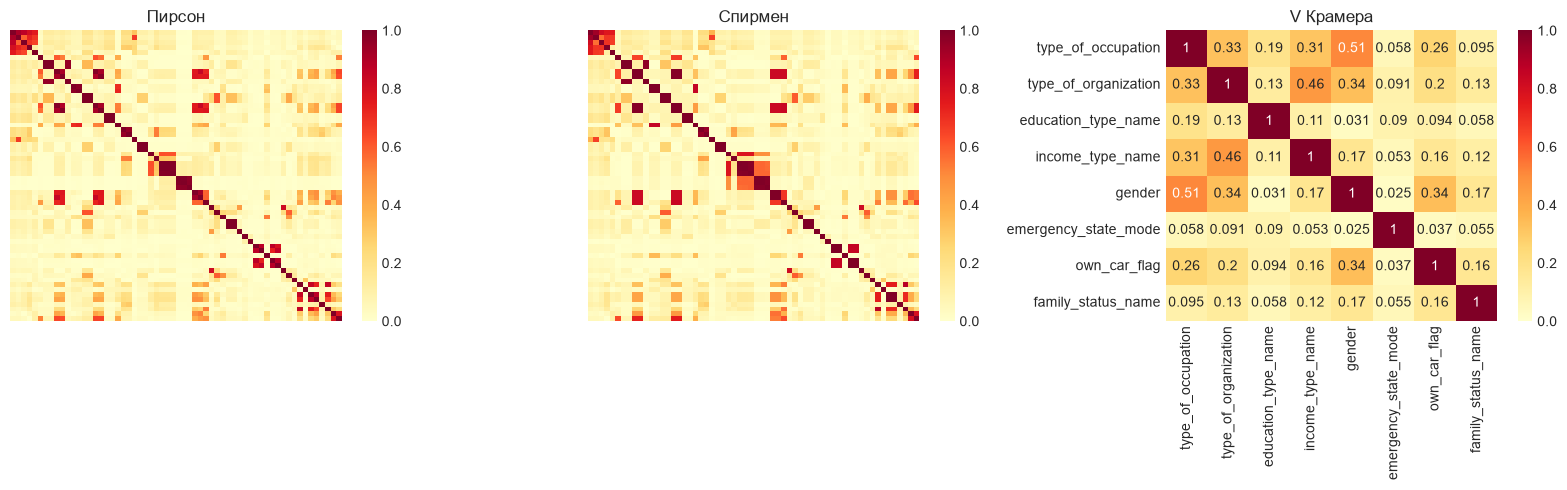

In [13]:
num_s2 = [c for c in X_train_s2.columns if c not in cat_cols_s2]
cat_s2 = list(cat_cols_s2)

# числа: Пирсон и Спирмен, в матрицу — максимум модуля
pearson_m = X_train_s2[num_s2].corr('pearson').abs().fillna(0)
spearman_m = X_train_s2[num_s2].corr('spearman').abs().fillna(0)

assoc = pd.DataFrame(
    np.eye(len(X_train_s2.columns)),
    index=X_train_s2.columns,
    columns=X_train_s2.columns,
)
assoc.loc[num_s2, num_s2] = np.maximum(pearson_m, spearman_m)

# категории — отдельно, своим циклом: V Крамера
for i, a in enumerate(cat_s2):
    for b in cat_s2[i + 1:]:
        v = association(pd.crosstab(X_train_s2[a], X_train_s2[b]), method='cramer')
        assoc.loc[a, b] = assoc.loc[b, a] = float(np.nan_to_num(v))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.heatmap(pearson_m, ax=axes[0], cmap='YlOrRd', vmin=0, vmax=1, xticklabels=False, yticklabels=False)
axes[0].set_title('Пирсон')
sns.heatmap(spearman_m, ax=axes[1], cmap='YlOrRd', vmin=0, vmax=1, xticklabels=False, yticklabels=False)
axes[1].set_title('Спирмен')
sns.heatmap(assoc.loc[cat_s2, cat_s2], ax=axes[2], cmap='YlOrRd', vmin=0, vmax=1, annot=len(cat_s2) <= 12)
axes[2].set_title('V Крамера')
plt.tight_layout()
plt.show()


## 7. Stage 3: жадный отбор по FSTR и корреляциям

Идём от большего FSTR к меньшему: признак берём в итог и выкидываем всех, у кого ассоциация ≥ порога.
Сколько оставить (`STAGE3_N`) и порог (`CORR_THR`) — два гиперпараметра, оба смотрим по Gini на **test**.


In [14]:
def greedy_uncorrelated(fstr: pd.Series, assoc_m: pd.DataFrame, corr_thr: float) -> list:
    ordered = fstr.sort_values(ascending=False).index.tolist()
    kept, banned = [], set()
    for col in ordered:
        if col in banned:
            continue
        kept.append(col)
        for other in ordered:
            if other == col or other in banned:
                continue
            if assoc_m.loc[col, other] >= corr_thr:
                banned.add(other)
    return kept


stage3_rows = []
for thr in CORR_THR_OPTIONS:
    greedy = greedy_uncorrelated(fstr_s2, assoc, thr)
    for n in STAGE3_N_OPTIONS:
        cols = greedy[: min(n, len(greedy))]
        model = fit_catboost(X_train_s2[cols], y_train, X_val_s2[cols], y_val, cat_cols_s2)
        gini_test = gini_score(y_test, model.predict_proba(X_test_s2[cols])[:, 1])
        stage3_rows.append({
            'corr_thr': thr,
            'n': n,
            'n_after_greedy': len(greedy),
            'n_used': len(cols),
            'gini_test': gini_test,
        })
        print(f'thr={thr:.2f}, n={n:2d}, после жадного={len(greedy):2d}, взяли={len(cols):2d}, Gini test={gini_test:.4f}')

stage3_search = pd.DataFrame(stage3_rows)
best_row = stage3_search.sort_values('gini_test', ascending=False).iloc[0]
best_corr_thr = float(best_row['corr_thr'])
best_stage3_n = int(best_row['n'])
print(f'\nЛучшие: corr_thr={best_corr_thr:.2f}, n={best_stage3_n}')
display(stage3_search)


thr=0.70, n=15, после жадного=37, взяли=15, Gini test=0.4760


thr=0.70, n=25, после жадного=37, взяли=25, Gini test=0.4774


thr=0.70, n=35, после жадного=37, взяли=35, Gini test=0.4847


thr=0.80, n=15, после жадного=41, взяли=15, Gini test=0.4767


thr=0.80, n=25, после жадного=41, взяли=25, Gini test=0.4804


thr=0.80, n=35, после жадного=41, взяли=35, Gini test=0.4785


thr=0.90, n=15, после жадного=48, взяли=15, Gini test=0.4741


thr=0.90, n=25, после жадного=48, взяли=25, Gini test=0.4798


thr=0.90, n=35, после жадного=48, взяли=35, Gini test=0.4794

Лучшие: corr_thr=0.70, n=35


,corr_thr,n,n_after_greedy,n_used,gini_test
0,0.700,15,37,15,0.476
1,0.700,25,37,25,0.477
2,0.700,35,37,35,0.485
3,0.800,15,41,15,0.477
4,0.800,25,41,25,0.480
5,0.800,35,41,35,0.479
6,0.900,15,48,15,0.474
7,0.900,25,48,25,0.480
8,0.900,35,48,35,0.479


In [15]:
greedy_best = greedy_uncorrelated(fstr_s2, assoc, best_corr_thr)
features_stage_3 = greedy_best[: min(best_stage3_n, len(greedy_best))]
cat_cols_s3 = [c for c in features_stage_3 if c in cat_cols_s2]

X_train_s3 = X_train_s2[features_stage_3]
X_val_s3 = X_val_s2[features_stage_3]
X_test_s3 = X_test_s2[features_stage_3]
X_late_s3 = X_late_s2[features_stage_3]

print(f'Пул stage_3: {len(features_stage_3)} признаков')
print(features_stage_3)


Пул stage_3: 35 признаков
['annuity_to_credit', 'ext_source_mean', 'education_type_name', 'days_employed', 'gender', 'days_birth', 'down_payment', 'annuity_income_ratio', 'docs_count', 'log_annuity', 'type_of_organization', 'years_since_phone_change', 'population_relative_region', 'own_car_flag', 'type_of_occupation', 'income_type_name', 'publication_timestamp', 'average_years_beginexpluatation', 'registration_timestamp', 'loan_per_family_member', 'ext_source_diff', 'rating_client_w_city_region', 'hour_of_approval_process_start', 'income_per_family_member', 'mode_total_area', 'work_phone_flag', 'requests_bki_year', 'social_default_rate_30', 'family_status_name', 'requests_bki_qrt', 'document_3_flag', 'emergency_state_mode', 'not_live_city_reg_city', 'employee_phone_flag', 'phone_flag']


## 8. Финальный CatBoost на stage_3

Снова `eval_set` = val. Дальше — порог и late_test.


In [16]:
cb_s3 = fit_catboost(X_train_s3, y_train, X_val_s3, y_val, cat_cols_s3)
proba_train = cb_s3.predict_proba(X_train_s3)[:, 1]
proba_val = cb_s3.predict_proba(X_val_s3)[:, 1]
proba_test = cb_s3.predict_proba(X_test_s3)[:, 1]

print(f'best iteration = {cb_s3.get_best_iteration()}')
print(f'Gini train = {gini_score(y_train, proba_train):.4f}')
print(f'Gini val   = {gini_score(y_val, proba_val):.4f}')
print(f'Gini test  = {gini_score(y_test, proba_test):.4f}')


best iteration = 200
Gini train = 0.6397
Gini val   = 0.4878
Gini test  = 0.4847


## 9. Калибровка: подбор порога

Gini порог не меняет. После порога смотрим **F1** по дефолту.
Порог подбираем на val, применяем к test.


In [17]:
thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)
thr_table = pd.DataFrame([classification_at_threshold(y_val, proba_val, t) for t in thresholds]).set_index('threshold')
print('Пороги CatBoost на val:')
display(thr_table.style.format('{:.3f}').background_gradient(subset=['F1'], cmap='YlGn'))

best_threshold = float(thr_table['F1'].idxmax())
print(f'\nЛучший порог по F1 на val: {best_threshold:.2f}  (F1 = {thr_table.loc[best_threshold, "F1"]:.3f})')


Пороги CatBoost на val:


,F1,Precision,Recall
threshold,,,
0.100000,0.154,0.084,0.996
0.150000,0.162,0.088,0.987
0.200000,0.174,0.095,0.957
0.250000,0.189,0.105,0.925
0.300000,0.203,0.115,0.876
0.350000,0.220,0.127,0.822
0.400000,0.235,0.139,0.758
0.450000,0.253,0.154,0.703
0.500000,0.268,0.170,0.634



Лучший порог по F1 на val: 0.65  (F1 = 0.290)


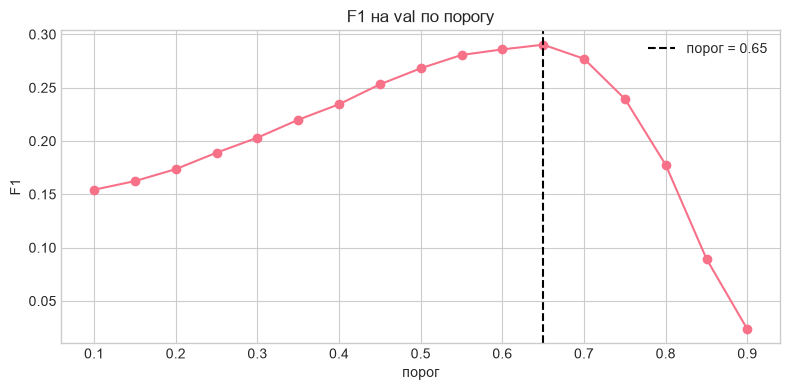

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thr_table.index, thr_table['F1'], marker='o')
ax.axvline(best_threshold, color='black', linestyle='--', label=f'порог = {best_threshold:.2f}')
ax.set_xlabel('порог')
ax.set_ylabel('F1')
ax.set_title('F1 на val по порогу')
ax.legend()
plt.tight_layout()
plt.show()


Test при пороге с val:
  F1         0.3003
  Precision  0.2402
  Recall     0.4003


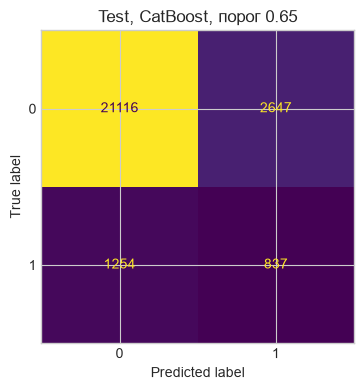

In [19]:
test_at_thr = classification_at_threshold(y_test, proba_test, best_threshold)
print('Test при пороге с val:')
for k, v in test_at_thr.items():
    if k != 'threshold':
        print(f'  {k:10s} {v:.4f}')

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, (proba_test >= best_threshold).astype(int)),
).plot(ax=ax, colorbar=False)
ax.set_title(f'Test, CatBoost, порог {best_threshold:.2f}')
plt.tight_layout()
plt.show()


## 10. Late test

Ни `n` для топов, ни порог корреляции, ни число stage_3, ни порог классификации здесь больше не крутим.


In [20]:
proba_late = cb_s3.predict_proba(X_late_s3)[:, 1]
late_at_thr = classification_at_threshold(y_late, proba_late, best_threshold)
print(f'Gini late_test = {gini_score(y_late, proba_late):.4f}')
print(f'F1   late_test = {late_at_thr["F1"]:.4f}   (порог {best_threshold:.2f}, выбран на val)')


Gini late_test = 0.5011
F1   late_test = 0.3070   (порог 0.65, выбран на val)


In [21]:
summary = pd.DataFrame([
    {
        'split': 'train (сэмпл)',
        'n': len(y_train),
        'Gini': gini_score(y_train, proba_train),
        'F1': classification_at_threshold(y_train, proba_train, best_threshold)['F1'],
    },
    {
        'split': 'val',
        'n': len(y_val),
        'Gini': gini_score(y_val, proba_val),
        'F1': classification_at_threshold(y_val, proba_val, best_threshold)['F1'],
    },
    {
        'split': 'test',
        'n': len(y_test),
        'Gini': gini_score(y_test, proba_test),
        'F1': test_at_thr['F1'],
    },
    {
        'split': 'late_test',
        'n': len(y_late),
        'Gini': gini_score(y_late, proba_late),
        'F1': late_at_thr['F1'],
    },
]).set_index('split')

print(
    f'Сводка версии 3  |  CatBoost  |  stage_2 n={best_stage2_n}  |  '
    f'corr_thr={best_corr_thr:.2f}  |  stage_3 n={len(features_stage_3)}'
)
summary


Сводка версии 3  |  CatBoost  |  stage_2 n=50  |  corr_thr=0.70  |  stage_3 n=35

,n,Gini,F1
split,,,
train (сэмпл),50000,0.640,0.352
val,25853,0.488,0.290
test,25854,0.485,0.300
late_test,25853,0.501,0.307


### Что запомнить из v3

1. Сплиты и новые фичи — как в v2; пропуски не удаляем и не заполняем, scaler и One-Hot не нужны.
2. Категории идут в `cat_features`, валидация — в `eval_set`.
3. Stage 2: union топов IV, F-score и FSTR; `n` выбираем по Gini на test.
4. Stage 3: жадно идём по FSTR и выкидываем коррелирующих; порог корреляции и число фичей — тоже по test.
5. Порог классификации — по F1 на val; late_test — один раз в конце.
